In [ ]:
#Import Libraries
print("Karthick N 24BAD055")
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import mean_squared_error
from math import sqrt

In [4]:
#Load the dataset
ratings = pd.read_csv("dataset/ratings.csv")
movies = pd.read_csv("dataset/movies.csv")

data = pd.merge(ratings, movies, on="movieId")

data.rename(columns={
    "userId": "user_id",
    "movieId": "movie_id",
    "rating": "rating",
    "title": "title"
}, inplace=True)

data.head()

,user_id,movie_id,rating,timestamp,title,genres
0,1,1,4.0,964982703,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,1,3,4.0,964981247,Grumpier Old Men (1995),Comedy|Romance
2,1,6,4.0,964982224,Heat (1995),Action|Crime|Thriller
3,1,47,5.0,964983815,Seven (a.k.a. Se7en) (1995),Mystery|Thriller
4,1,50,5.0,964982931,"Usual Suspects, The (1995)",Crime|Mystery|Thriller


In [5]:
#Creating item-user matrix
item_user_matrix = data.pivot_table(index='title', columns='user_id', values='rating')

item_user_matrix.head()

user_id,1,2,3,4,5,6,7,8,9,10,...,601,602,603,604,605,606,607,608,609,610
title,,,,,,,,,,,,,,,,,,,,,
'71 (2014),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.0
'Hellboy': The Seeds of Creation (2004),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
'Round Midnight (1986),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
'Salem's Lot (2004),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
'Til There Was You (1997),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
#Handling missing values
item_user_filled = item_user_matrix.fillna(0)

In [7]:
#Compute item-similarity]
item_similarity = cosine_similarity(item_user_filled)

item_similarity_df = pd.DataFrame(
    item_similarity,
    index=item_user_matrix.index,
    columns=item_user_matrix.index
)

item_similarity_df.head()

title,'71 (2014),'Hellboy': The Seeds of Creation (2004),'Round Midnight (1986),'Salem's Lot (2004),'Til There Was You (1997),'Tis the Season for Love (2015),"'burbs, The (1989)",'night Mother (1986),(500) Days of Summer (2009),*batteries not included (1987),...,Zulu (2013),[REC] (2007),[REC]² (2009),[REC]³ 3 Génesis (2012),anohana: The Flower We Saw That Day - The Movie (2013),eXistenZ (1999),xXx (2002),xXx: State of the Union (2005),¡Three Amigos! (1986),À nous la liberté (Freedom for Us) (1931)
title,,,,,,,,,,,,,,,,,,,,,
'71 (2014),1.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.141653,0.0,...,0.0,0.342055,0.543305,0.707107,0.0,0.0,0.139431,0.327327,0.0,0.0
'Hellboy': The Seeds of Creation (2004),0.0,1.000000,0.707107,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0.0,...,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.0
'Round Midnight (1986),0.0,0.707107,1.000000,0.000000,0.000000,0.0,0.176777,0.0,0.000000,0.0,...,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.0
'Salem's Lot (2004),0.0,0.000000,0.000000,1.000000,0.857493,0.0,0.000000,0.0,0.000000,0.0,...,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.0
'Til There Was You (1997),0.0,0.000000,0.000000,0.857493,1.000000,0.0,0.000000,0.0,0.000000,0.0,...,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.0


In [8]:
#Final top-similar items
def get_similar_items(movie_title, n=5):
    similar_items = item_similarity_df[movie_title].sort_values(ascending=False)[1:n+1]
    return similar_items

# Example
get_similar_items("Toy Story (1995)", 5)

title
Toy Story 2 (1999)                           0.572601
Jurassic Park (1993)                         0.565637
Independence Day (a.k.a. ID4) (1996)         0.564262
Star Wars: Episode IV - A New Hope (1977)    0.557388
Forrest Gump (1994)                          0.547096
Name: Toy Story (1995), dtype: float64

In [23]:
#Recommend items based on user history
def recommend_item_based(user_id, n=5):
    user_ratings = item_user_filled[user_id]
    
    rated_items = user_ratings[user_ratings > 0]
    
    scores = {}
    similarity_sums = {}
    
    for item in rated_items.index:
        similarity_scores = item_similarity_df[item]
        
        for similar_item, sim in similarity_scores.items():
            if user_ratings[similar_item] == 0:
                scores[similar_item] = scores.get(similar_item, 0) + sim * rated_items[item]
                similarity_sums[similar_item] = similarity_sums.get(similar_item, 0) + sim
    
    predicted_ratings = {}
    for item in scores:
        if similarity_sums[item] != 0:
            predicted_ratings[item] = scores[item] / similarity_sums[item]
    
    return pd.Series(predicted_ratings).sort_values(ascending=False).head(n)

recommend_item_based(1,5)

recommend_item_based(100,120)

Too Late for Tears (1949)                               5.000000
Villain (1971)                                          5.000000
Pearl Jam Twenty (2011)                                 4.500000
Carabineers, The (Carabiniers, Les) (1963)              4.500000
Ring, The (1927)                                        4.500000
                                                          ...   
Disgrace (2008)                                         4.200971
The True Memoirs of an International Assassin (2016)    4.199201
Rough Night (2017)                                      4.197726
The Boss Baby (2017)                                    4.196513
Death Sentence (2007)                                   4.194910
Length: 120, dtype: float64

In [10]:
#RMSE Evaluation
predicted_matrix = np.dot(item_similarity, item_user_filled) / np.array([np.abs(item_similarity).sum(axis=1)]).T

actual = item_user_filled.values.flatten()
predicted = predicted_matrix.flatten()

mask = actual > 0
actual = actual[mask]
predicted = predicted[mask]

rmse = sqrt(mean_squared_error(actual, predicted))

print("RMSE:", rmse)

RMSE: 3.1456882806620725


In [11]:
#Precision@K
def precision_at_k(user_id, k=5, threshold=3.5):
    recommended = recommend_item_based(user_id, k)
    
    actual_ratings = item_user_filled[user_id]
    
    relevant = actual_ratings[actual_ratings >= threshold].index
    
    recommended_items = recommended.index
    
    relevant_recommended = [item for item in recommended_items if item in relevant]
    
    precision = len(relevant_recommended) / k
    
    return precision

precision_at_k(1, 5)

0.0

In [12]:
#User-based
user_item_matrix = data.pivot_table(index='user_id', columns='title', values='rating').fillna(0)

user_similarity = cosine_similarity(user_item_matrix)

def recommend_user_based(user_id, n=5):
    sim_scores = user_similarity[user_id - 1]
    similar_users = np.argsort(sim_scores)[::-1][1:6]
    
    weighted_ratings = np.dot(sim_scores[similar_users], user_item_matrix.iloc[similar_users])
    predicted = weighted_ratings / np.sum(sim_scores[similar_users])
    
    predicted_series = pd.Series(predicted, index=user_item_matrix.columns)
    
    already_rated = user_item_matrix.loc[user_id]
    predicted_series = predicted_series[already_rated == 0]
    
    return predicted_series.sort_values(ascending=False).head(n)


recommend_user_based(1, 5)

title
Aliens (1986)                        4.801002
Hunt for Red October, The (1990)     4.298950
Blade Runner (1982)                  4.004742
Terminator 2: Judgment Day (1991)    4.003711
Die Hard (1988)                      4.000000
dtype: float64

In [13]:
#Comparing recommendations
user_id = 1

item_based = recommend_item_based(user_id, 5)
user_based = recommend_user_based(user_id, 5)

print("Item-Based:\n", item_based)
print("\nUser-Based:\n", user_based)

Item-Based:
 Ferris Bueller's Day Off (1986)    352.684010
Die Hard (1988)                    330.949884
Breakfast Club, The (1985)         328.180507
Fifth Element, The (1997)          326.437374
Aliens (1986)                      323.117648
dtype: float64

User-Based:
 title
Aliens (1986)                        4.801002
Hunt for Red October, The (1990)     4.298950
Blade Runner (1982)                  4.004742
Terminator 2: Judgment Day (1991)    4.003711
Die Hard (1988)                      4.000000
dtype: float64


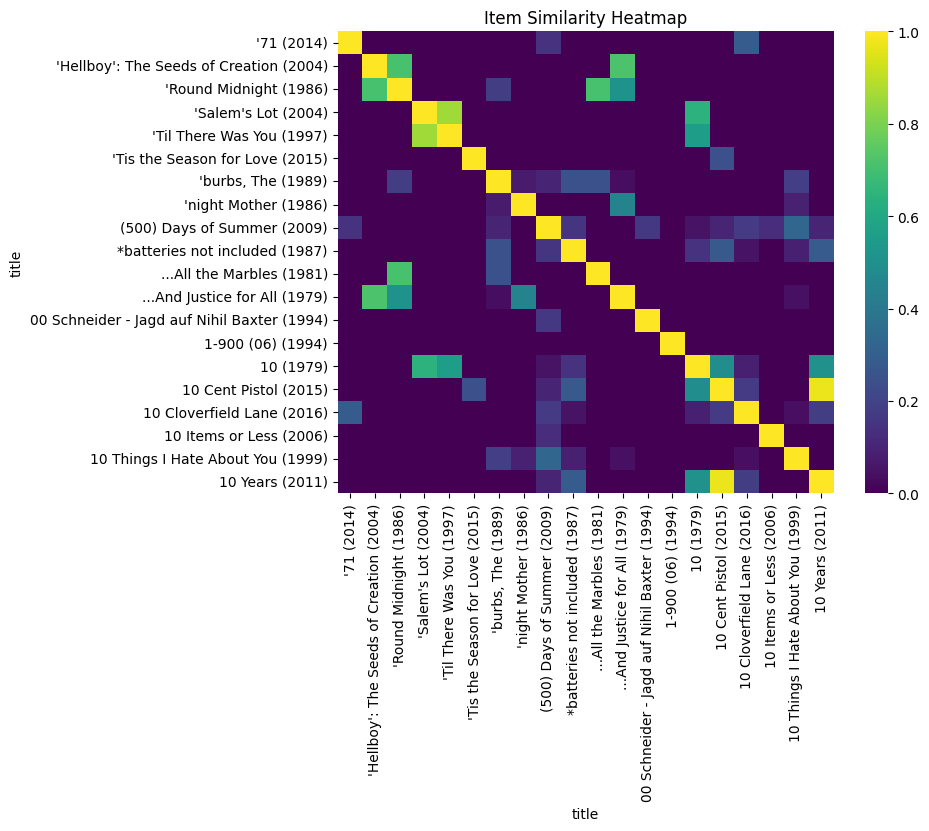

In [14]:
#Visualization
#Item-similarity heatmap
plt.figure(figsize=(8,6))
sns.heatmap(item_similarity_df.iloc[:20, :20], cmap="viridis")
plt.title("Item Similarity Heatmap")
plt.show()

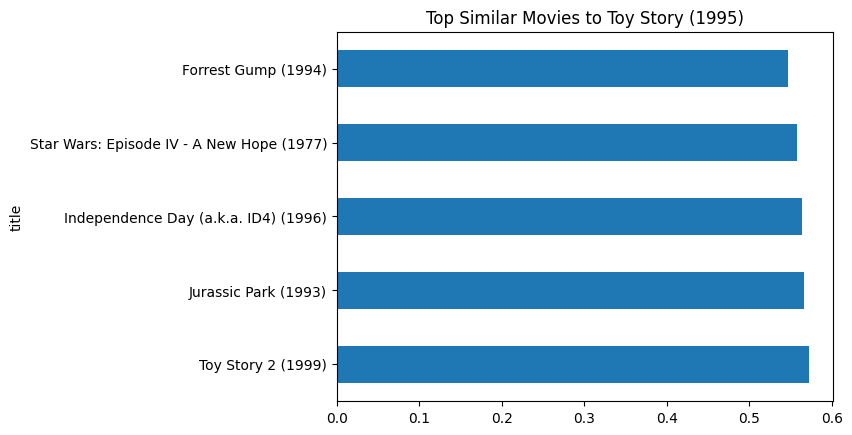

In [15]:
#Top-similar Item-graph
movie = "Toy Story (1995)"
similar_items = get_similar_items(movie, 5)

similar_items.plot(kind='barh')
plt.title(f"Top Similar Movies to {movie}")
plt.show()

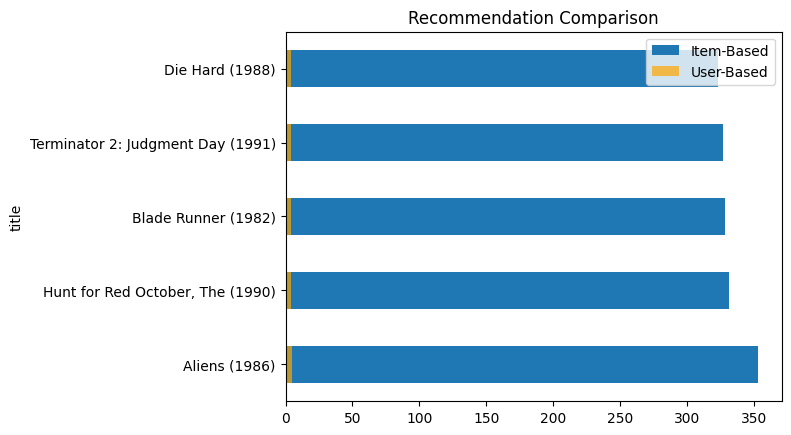

In [16]:
#Recommendation Comparision chart
item_based.plot(kind='barh', label='Item-Based')
user_based.plot(kind='barh', color='orange', alpha=0.7, label='User-Based')

plt.legend()
plt.title("Recommendation Comparison")
plt.show()